<a href="https://www.kaggle.com/code/sonawanelalitsunil/mastercard-incorporated-ma-stock-ml-99-98?scriptVersionId=227129087" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mastercard-stock-data-latest-and-updated/Mastercard_stock_info.csv
/kaggle/input/mastercard-stock-data-latest-and-updated/Mastercard_stock_history.csv


## Title: Mastercard Incorporated (MA) Stock Overview

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/mastercard-stock-data-latest-and-updated/Mastercard_stock_history.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2006-05-25,3.748967,4.283869,3.739664,4.279217,395343000,0.0,0.0
1,2006-05-26,4.307126,4.348058,4.103398,4.179680,103044000,0.0,0.0
2,2006-05-30,4.183400,4.184330,3.986184,4.093164,49898000,0.0,0.0
3,2006-05-31,4.125723,4.219679,4.125723,4.180608,30002000,0.0,0.0
4,2006-06-01,4.179678,4.474572,4.176887,4.419686,62344000,0.0,0.0


In [4]:
df.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
3867,2021-10-05,347.121403,348.130138,342.497241,342.776886,4724100,0.00,0.0
3868,2021-10-06,339.580960,348.439763,338.682072,348.250000,3712000,0.00,0.0
3869,2021-10-07,349.000000,357.899994,349.000000,353.910004,3209200,0.44,0.0
3870,2021-10-08,356.000000,360.369995,354.209991,354.959991,2336700,0.00,0.0
3871,2021-10-11,353.950012,354.880005,346.899994,347.149994,2766800,0.00,0.0


In [5]:
df.dtypes

Date             object
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

In [6]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3872.000000,3872.000000,3872.000000,3872.000000,3.872000e+03,3872.000000,3872.000000
mean,104.896814,105.956054,103.769349,104.882714,1.232250e+07,0.002329,0.002583
std,106.245511,107.303589,105.050064,106.168693,1.759665e+07,0.025851,0.160706
min,3.748967,4.102467,3.739664,4.083861,6.411000e+05,0.000000,0.000000
25%,22.347203,22.637997,22.034458,22.300391,3.529475e+06,0.000000,0.000000
50%,70.810079,71.375896,70.224002,70.856083,5.891750e+06,0.000000,0.000000
75%,147.688448,148.645373,146.822013,147.688438,1.319775e+07,0.000000,0.000000
max,392.653890,400.521479,389.747812,394.685730,3.953430e+08,0.440000,10.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3872 entries, 0 to 3871
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          3872 non-null   object 
 1   Open          3872 non-null   float64
 2   High          3872 non-null   float64
 3   Low           3872 non-null   float64
 4   Close         3872 non-null   float64
 5   Volume        3872 non-null   int64  
 6   Dividends     3872 non-null   float64
 7   Stock Splits  3872 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 242.1+ KB


In [8]:
df. corr

<bound method DataFrame.corr of             Date        Open        High         Low       Close     Volume  \
0     2006-05-25    3.748967    4.283869    3.739664    4.279217  395343000   
1     2006-05-26    4.307126    4.348058    4.103398    4.179680  103044000   
2     2006-05-30    4.183400    4.184330    3.986184    4.093164   49898000   
3     2006-05-31    4.125723    4.219679    4.125723    4.180608   30002000   
4     2006-06-01    4.179678    4.474572    4.176887    4.419686   62344000   
...          ...         ...         ...         ...         ...        ...   
3867  2021-10-05  347.121403  348.130138  342.497241  342.776886    4724100   
3868  2021-10-06  339.580960  348.439763  338.682072  348.250000    3712000   
3869  2021-10-07  349.000000  357.899994  349.000000  353.910004    3209200   
3870  2021-10-08  356.000000  360.369995  354.209991  354.959991    2336700   
3871  2021-10-11  353.950012  354.880005  346.899994  347.149994    2766800   

      Dividends  St

In [9]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe(include='all')

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3872,3872.000000,3872.000000,3872.000000,3872.000000,3.872000e+03,3872.000000,3872.000000
unique,3872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2006-05-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,104.896814,105.956054,103.769349,104.882714,1.232250e+07,0.002329,0.002583
std,NaN,106.245511,107.303589,105.050064,106.168693,1.759665e+07,0.025851,0.160706
min,NaN,3.748967,4.102467,3.739664,4.083861,6.411000e+05,0.000000,0.000000
25%,NaN,22.347203,22.637997,22.034458,22.300391,3.529475e+06,0.000000,0.000000
50%,NaN,70.810079,71.375896,70.224002,70.856083,5.891750e+06,0.000000,0.000000
75%,NaN,147.688448,148.645373,146.822013,147.688438,1.319775e+07,0.000000,0.000000


In [12]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

## Data visualizations

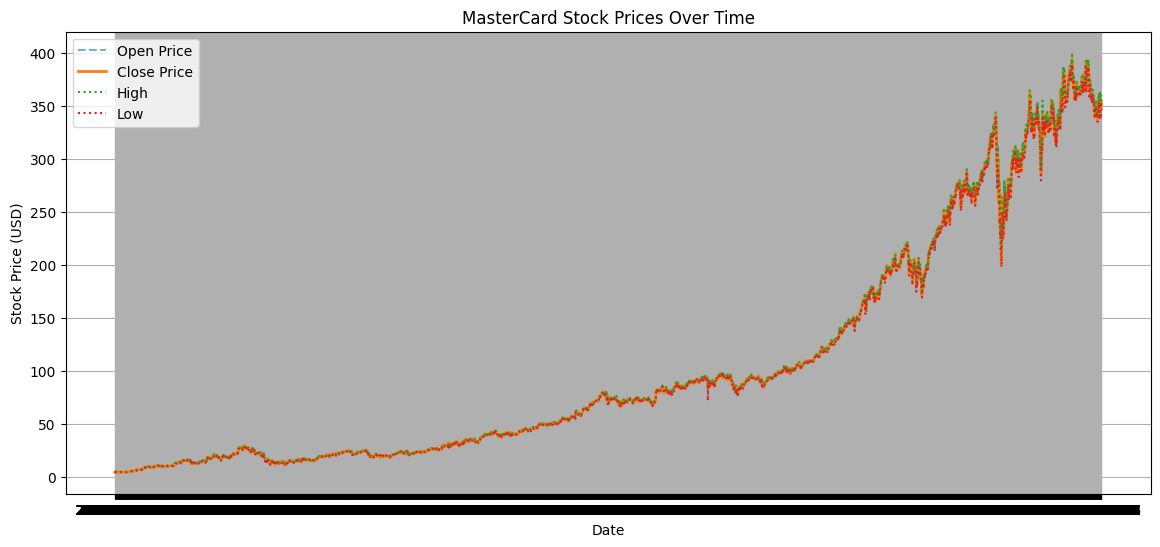

In [13]:
df.set_index('Date', inplace=True)

# Plot Stock Prices (Open, Close, High, Low)
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Open'], label='Open Price', linestyle='dashed', alpha=0.6)
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.plot(df.index, df['High'], label='High', linestyle='dotted')
plt.plot(df.index, df['Low'], label='Low', linestyle='dotted')
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("MasterCard Stock Prices Over Time")
plt.legend()
plt.grid(True)
plt.show()

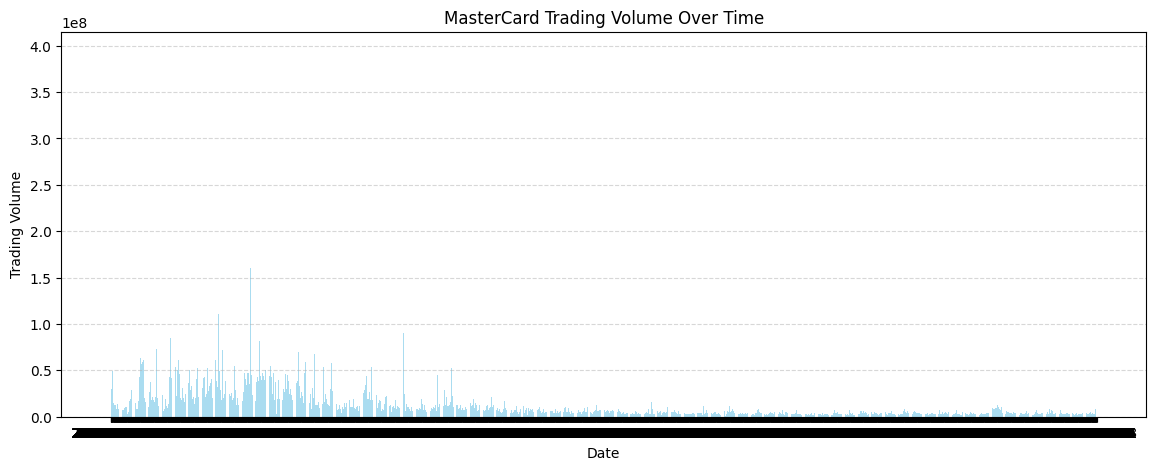

In [14]:
plt.figure(figsize=(14,5))
plt.bar(df.index, df['Volume'], color='skyblue', alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.title("MasterCard Trading Volume Over Time")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

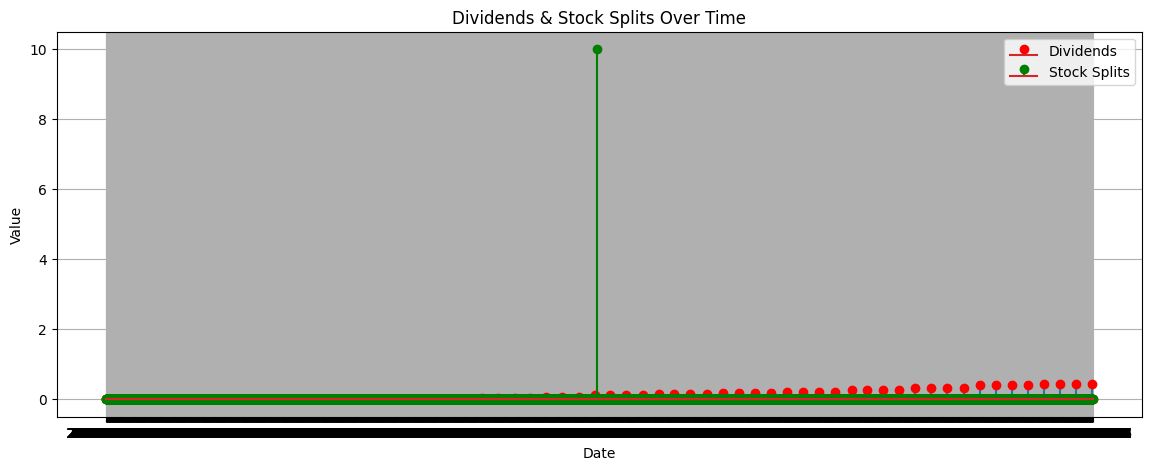

In [15]:
fig, ax = plt.subplots(figsize=(14,5))
ax.stem(df.index, df['Dividends'], markerfmt='ro', label="Dividends")
ax.stem(df.index, df['Stock Splits'], markerfmt='go', linefmt='g-', label="Stock Splits")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Dividends & Stock Splits Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import plotly.graph_objects as go

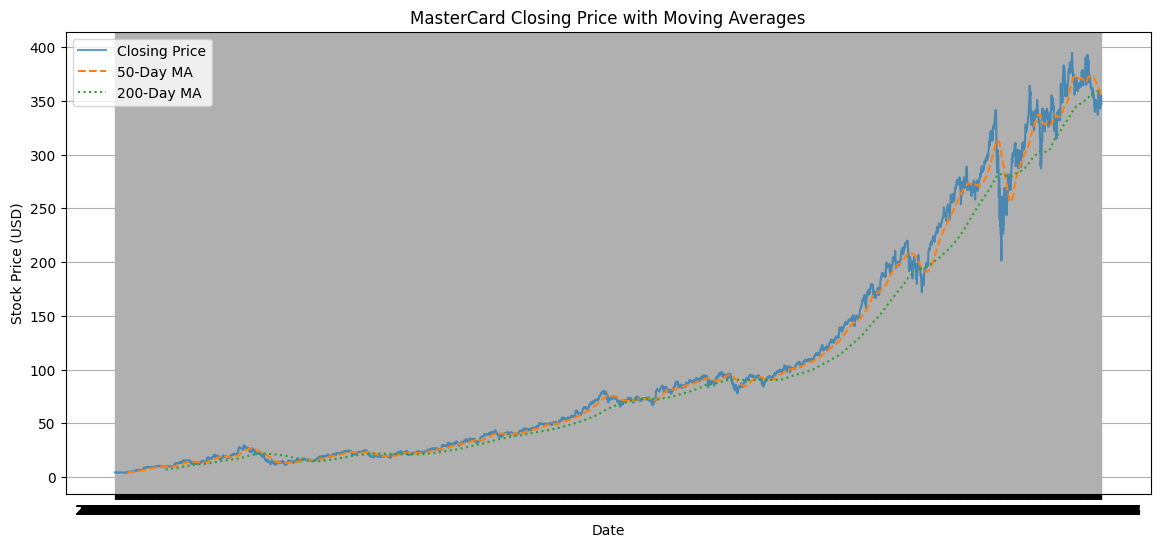

In [17]:
fig = go.Figure(data=[go.Candlestick(x=df.index,
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'],
                                     increasing_line_color='green',
                                     decreasing_line_color='red')])
fig.update_layout(title="MasterCard Candlestick Chart",
                  xaxis_title="Date",
                  yaxis_title="Price (USD)",
                  template="plotly_dark")
fig.show()

# Moving Averages (50-day & 200-day)
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label="Closing Price", alpha=0.7)
plt.plot(df.index, df['MA_50'], label="50-Day MA", linestyle="dashed")
plt.plot(df.index, df['MA_200'], label="200-Day MA", linestyle="dotted")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("MasterCard Closing Price with Moving Averages")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
pip install summarytools

Note: you may need to restart the kernel to use updated packages.


In [19]:
from summarytools import dfSummary

In [20]:
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,Open[float64],Mean (sd) : 104.9 (106.2)min < med < max:3.7 < 70.8 < 392.7IQR (CV) : 125.3 (1.0),"3,872 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACg0lEQVR4nO3dO4saURiH8ffEXT1eMoMXtPMLLKQQbGzSpcyHTZsugkJqv4GNCOIFzYqjmCZKIGF1ZmLGvzy/es+8Uzw6rng47ng8GnDv3mV9A8A1ni79gXOuaGb5hNffHY/H14RrgbM3Q3XOFev1+ucgCKpJLr5arebOuS/EirQuvaPmgyCo9nq91zAMt3EuvFwu/WAwqM5ms7yZESpSufjoNzMLw3DbbDZ/JLh+McEa4A/8MwUJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJV52KkhUOY8PJ3YbKYWz43U1DPRwOz2YWOOeSLA8qlUqz1+utOIwNNwt1s9k8R1H0od1u53K5XKzQzMyiKPKHw+GlUCh84zA23CzU3W735L0vdTqdbavVmsddPx6Pq6PRqLTf73O3uD9oufln1HK5nOh4yvl8zjsizvh6ChIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRLu9ofTWWN3wX0h1L/IcndByheIWYoXSZazL3nYULPcXdDv95uz2azhnFvFnOtrtdqnMAzLMdedLRaLtXPuq5nF/bF6lrPNLkT+kKFmubsgzewoiryZvXS73e+NRiNu5DaZTN4Ph8OP7Xa7oTTb7PJT6CFDzXJ3QZrZp7ne+yjpj80VZ1+zx+0hQz3JcndBktn/aleD2uxf3pzP11OQQKiQcNWjf7lc+rgXXq/X3sxss9n46XRa+p/rVWer3nfa9df09RN8im3CvtAeqAAAAABJRU5ErkJggg=="">",0(0.0%)
2,High[float64],Mean (sd) : 106.0 (107.3)min < med < max:4.1 < 71.4 < 400.5IQR (CV) : 126.0 (1.0),"3,871 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACZklEQVR4nO3dz2riUBiG8e+MVeMfThBBd97AwCxc5iLmYucSuvAKvAN3BQkRMwZjzGymZWBKo0ltfOX5rXvyBfqQpuLhuLIsDbh339q+AeAST1U/4JwbmFmv5vWPZVkeaq4F3nwYqnNuMJ1Of3rvJ3UuvtvtYufcL2JFU1VP1J73fhJF0SEMw+yaCydJEqxWq8l2u+2ZGaGikco//WZmYRhms9nsd43rD2qsAf7DP1OQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQQKiQcNGpKG3hMDa8uttQOYwN/7ppqEVRdM3MO+fqLPfj8XgWRdGOw9hws1DTNO3mef5jsVh0Op3OVaGZmeV5HhRF8b3f7z9zGBtuFurxeHwKgmC4XC6z+XweX7t+s9lM1uv18HQ6dW5xf9By83fU0WhU63jKOI55IuINH09BAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCwt1+cbptbe0uaDhXdnYVQn1HW7sLms5VnX0JQn1fz3s/iaLo8MW7C2rPFZ9d6WFDbboN5nw+d8MwjOt8l7YoCl9zdqO5wrPNKl4bHjLUz9oGk2XZs5ld9UtrMrvJXOXZZtWvDQ8ZapvbYJrMbrr9RnX2Ja8NDxnqqza3wdSZ/Vnbb9Rm//XhfD5HhYSLnqhJkgTXXni/3wdmZmmaBi8vL8OvXK86W/W+m66/pK8/Qnq0mC6GTs4AAAAASUVORK5CYII="">",0(0.0%)
3,Low[float64],Mean (sd) : 103.8 (105.1)min < med < max:3.7 < 70.2 < 389.7IQR (CV) : 124.8 (1.0),"3,872 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACoklEQVR4nO3dv07bUBiG8e80/Dkhqa3gKGy+AaQOSFm8dOvIxXbtViQideYOWBCSZRzFBcVY7lJYWpHYJiRv9PxmzjkZnmCC8um4uq4N2HWftv0CgHUcrPoB51zfzI5a7r+s6/qx5Vrg1ZuhOuf6URRdBkEwarP5fD7PnHPfiRVdrfqNehQEwShJkscwDJ+abJznub++vh6laXpkZoSKTlY++s3MwjB8mkwmv1vs32+xBvgHH6YggVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhgVAhYa1bUbaFy9jwYqOhVlV1aGaBc67Ncn96evotDMNBm8VcxrZfNhZqURSHZVl+ieO41+v1Gl2mZmZWlqU3s/PpdPprPB7Pm6zlMrb9s7FQl8vlgff+5OLi4uns7Cxruv729nZ0c3Nz4r0vuYwNG/8bdTAYtLr1L8syQsMrPvVDAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCAqFCwk5/w3+bmC7YLYT6H865fhRFl0EQjNqs7zJd0PENYtbhTbLNs1fZ21A7jsEEw+FwkiTJPAzDRtMJeZ77q6urSZqmY+dco8kE6zh+Y2b28PCwcM79MLOmUxXbPNtsReR7Gep7jMFUVXV+fHz8s+mXvruc3WX8xszs7u7u82w2+xrH8VjpbLPVT6G9DPW9xmCen597H3l21/GbLMv6imevM+O2l6G+2OYYTJuz32v8Ru3sv948n39PQQKhQsJaj/48z33TjReLhTczK4rC39/fn3zketWzVV931/Xr9PUH5uVnhm44koUAAAAASUVORK5CYII="">",0(0.0%)
4,Close[float64],Mean (sd) : 104.9 (106.2)min < med < max:4.1 < 70.9 < 394.7IQR (CV) : 125.4 (1.0),"3,796 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjc

In [21]:
df.nunique()

Open            3872
High            3871
Low             3872
Close           3796
Volume          3756
Dividends         13
Stock Splits       2
MA_50           3822
MA_200          3673
dtype: int64

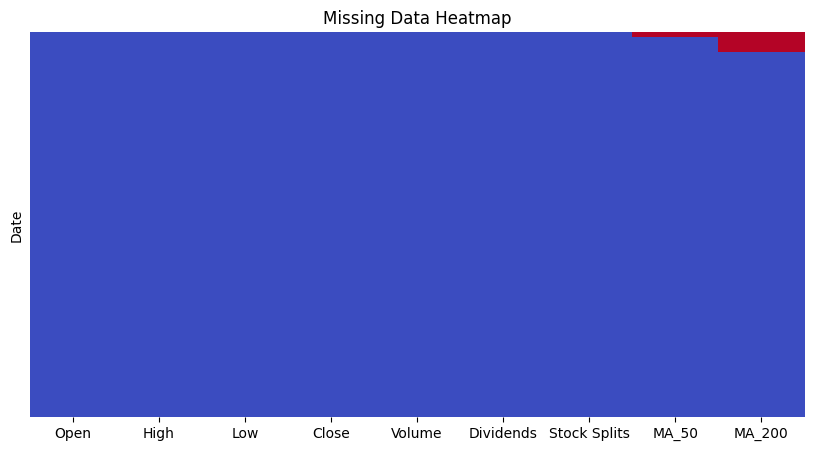

In [22]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cmap='coolwarm', cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

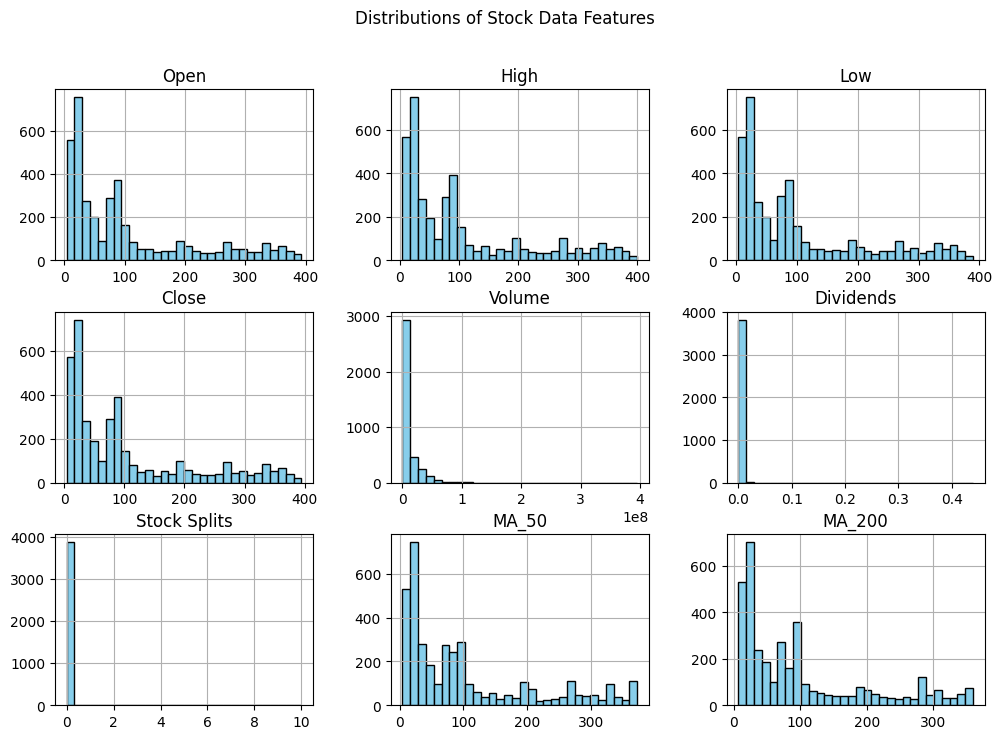

In [23]:
df.hist(figsize=(12,8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distributions of Stock Data Features")
plt.show()

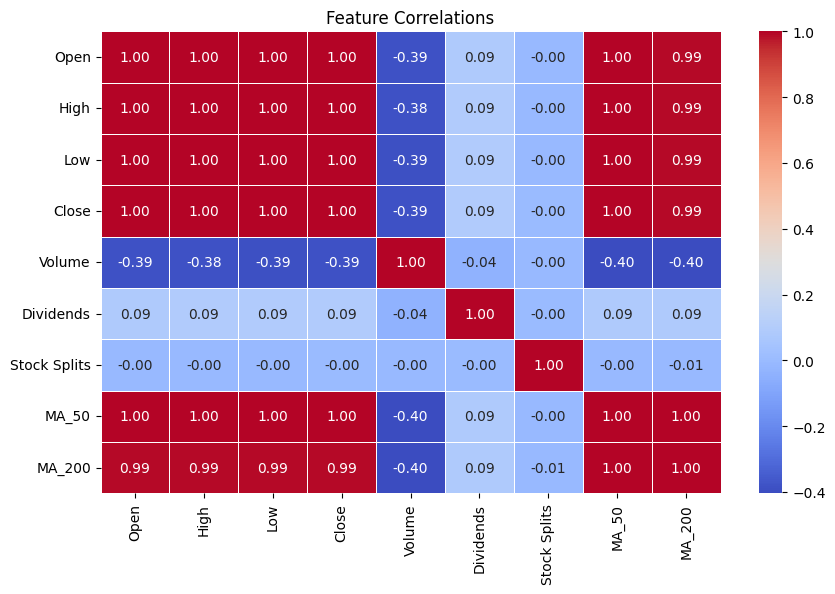

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlations")
plt.show()

In [25]:
from scipy import stats

z_scores = stats.zscore(df.select_dtypes(include=['float64', 'int64']))
z_scores

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_50,MA_200
Date,,,,,,,,,
2006-05-25,-0.952143,-0.947641,-0.952333,-0.947704,21.769480,-0.090107,-0.016073,NaN,NaN
2006-05-26,-0.946889,-0.947043,-0.948870,-0.948642,5.156277,-0.090107,-0.016073,NaN,NaN
2006-05-30,-0.948053,-0.948569,-0.949986,-0.949457,2.135653,-0.090107,-0.016073,NaN,NaN
2006-05-31,-0.948596,-0.948240,-0.948657,-0.948633,1.004838,-0.090107,-0.016073,NaN,NaN
2006-06-01,-0.948088,-0.945864,-0.948170,-0.946381,2.843038,-0.090107,-0.016073,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2021-10-05,2.280152,2.257197,2.272809,2.241008,-0.431865,-0.090107,-0.016073,NaN,NaN
2021-10-06,2.209171,2.260083,2.236487,2.292566,-0.489389,-0.090107,-0.016073,NaN,NaN
2021-10-07,2.297836,2.348258,2.334718,2.345884,-0.517967,16.932811,-0.016073,NaN,NaN


In [26]:
from scipy.stats.mstats import winsorize

df_winsorized = df.copy()
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df_winsorized[col] = winsorize(df[col], limits=[0.01, 0.01])  # Capping at 1% tails


In [27]:
df[df['Close']==df['Close'].min()]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_50,MA_200
Date,,,,,,,,,
2006-07-18,4.092234,4.102467,4.062465,4.083861,12483000,0.0,0.0,NaN,NaN


In [28]:
df[df['Close']==df['Close'].max()]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_50,MA_200
Date,,,,,,,,,
2021-04-28,389.747812,400.521479,389.747812,394.68573,4065300,0.0,0.0,367.473881,339.511124


In [29]:
df[df['Volume']==df['Volume'].min()]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_50,MA_200
Date,,,,,,,,,
2019-12-24,294.915536,295.261966,293.569447,294.44046,641100,0.0,0.0,279.766944,263.224261


In [30]:
df[df['Volume']==df['Volume'].max()]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_50,MA_200
Date,,,,,,,,,
2006-05-25,3.748967,4.283869,3.739664,4.279217,395343000,0.0,0.0,NaN,NaN


In [31]:
df_no_outliers = df[(z_scores < 3).all(axis=1) & (z_scores > -3).all(axis=1)]
print(f"Number of rows after outlier removal: {df_no_outliers.shape[0]}")

Number of rows after outlier removal: 0


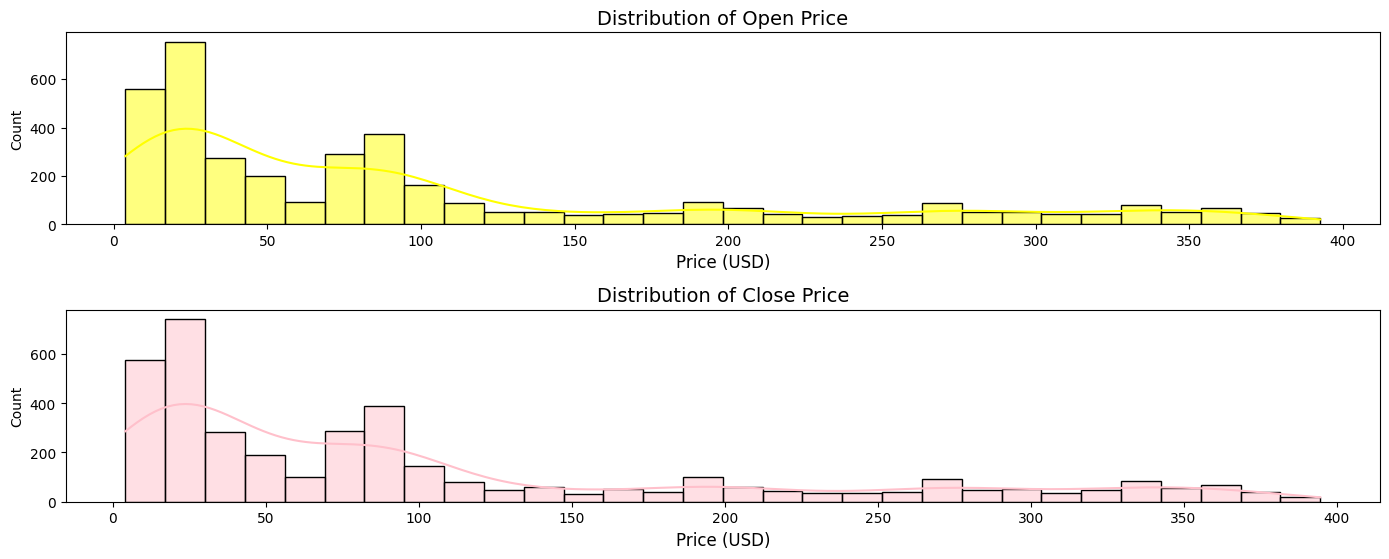

In [32]:
plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
sns.histplot(df['Open'], kde=True, color='yellow', bins=30)
plt.title('Distribution of Open Price', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)

plt.subplot(3, 1, 2)
sns.histplot(df['Close'], kde=True, color='pink', bins=30)
plt.title('Distribution of Close Price', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)


plt.tight_layout()
plt.show()

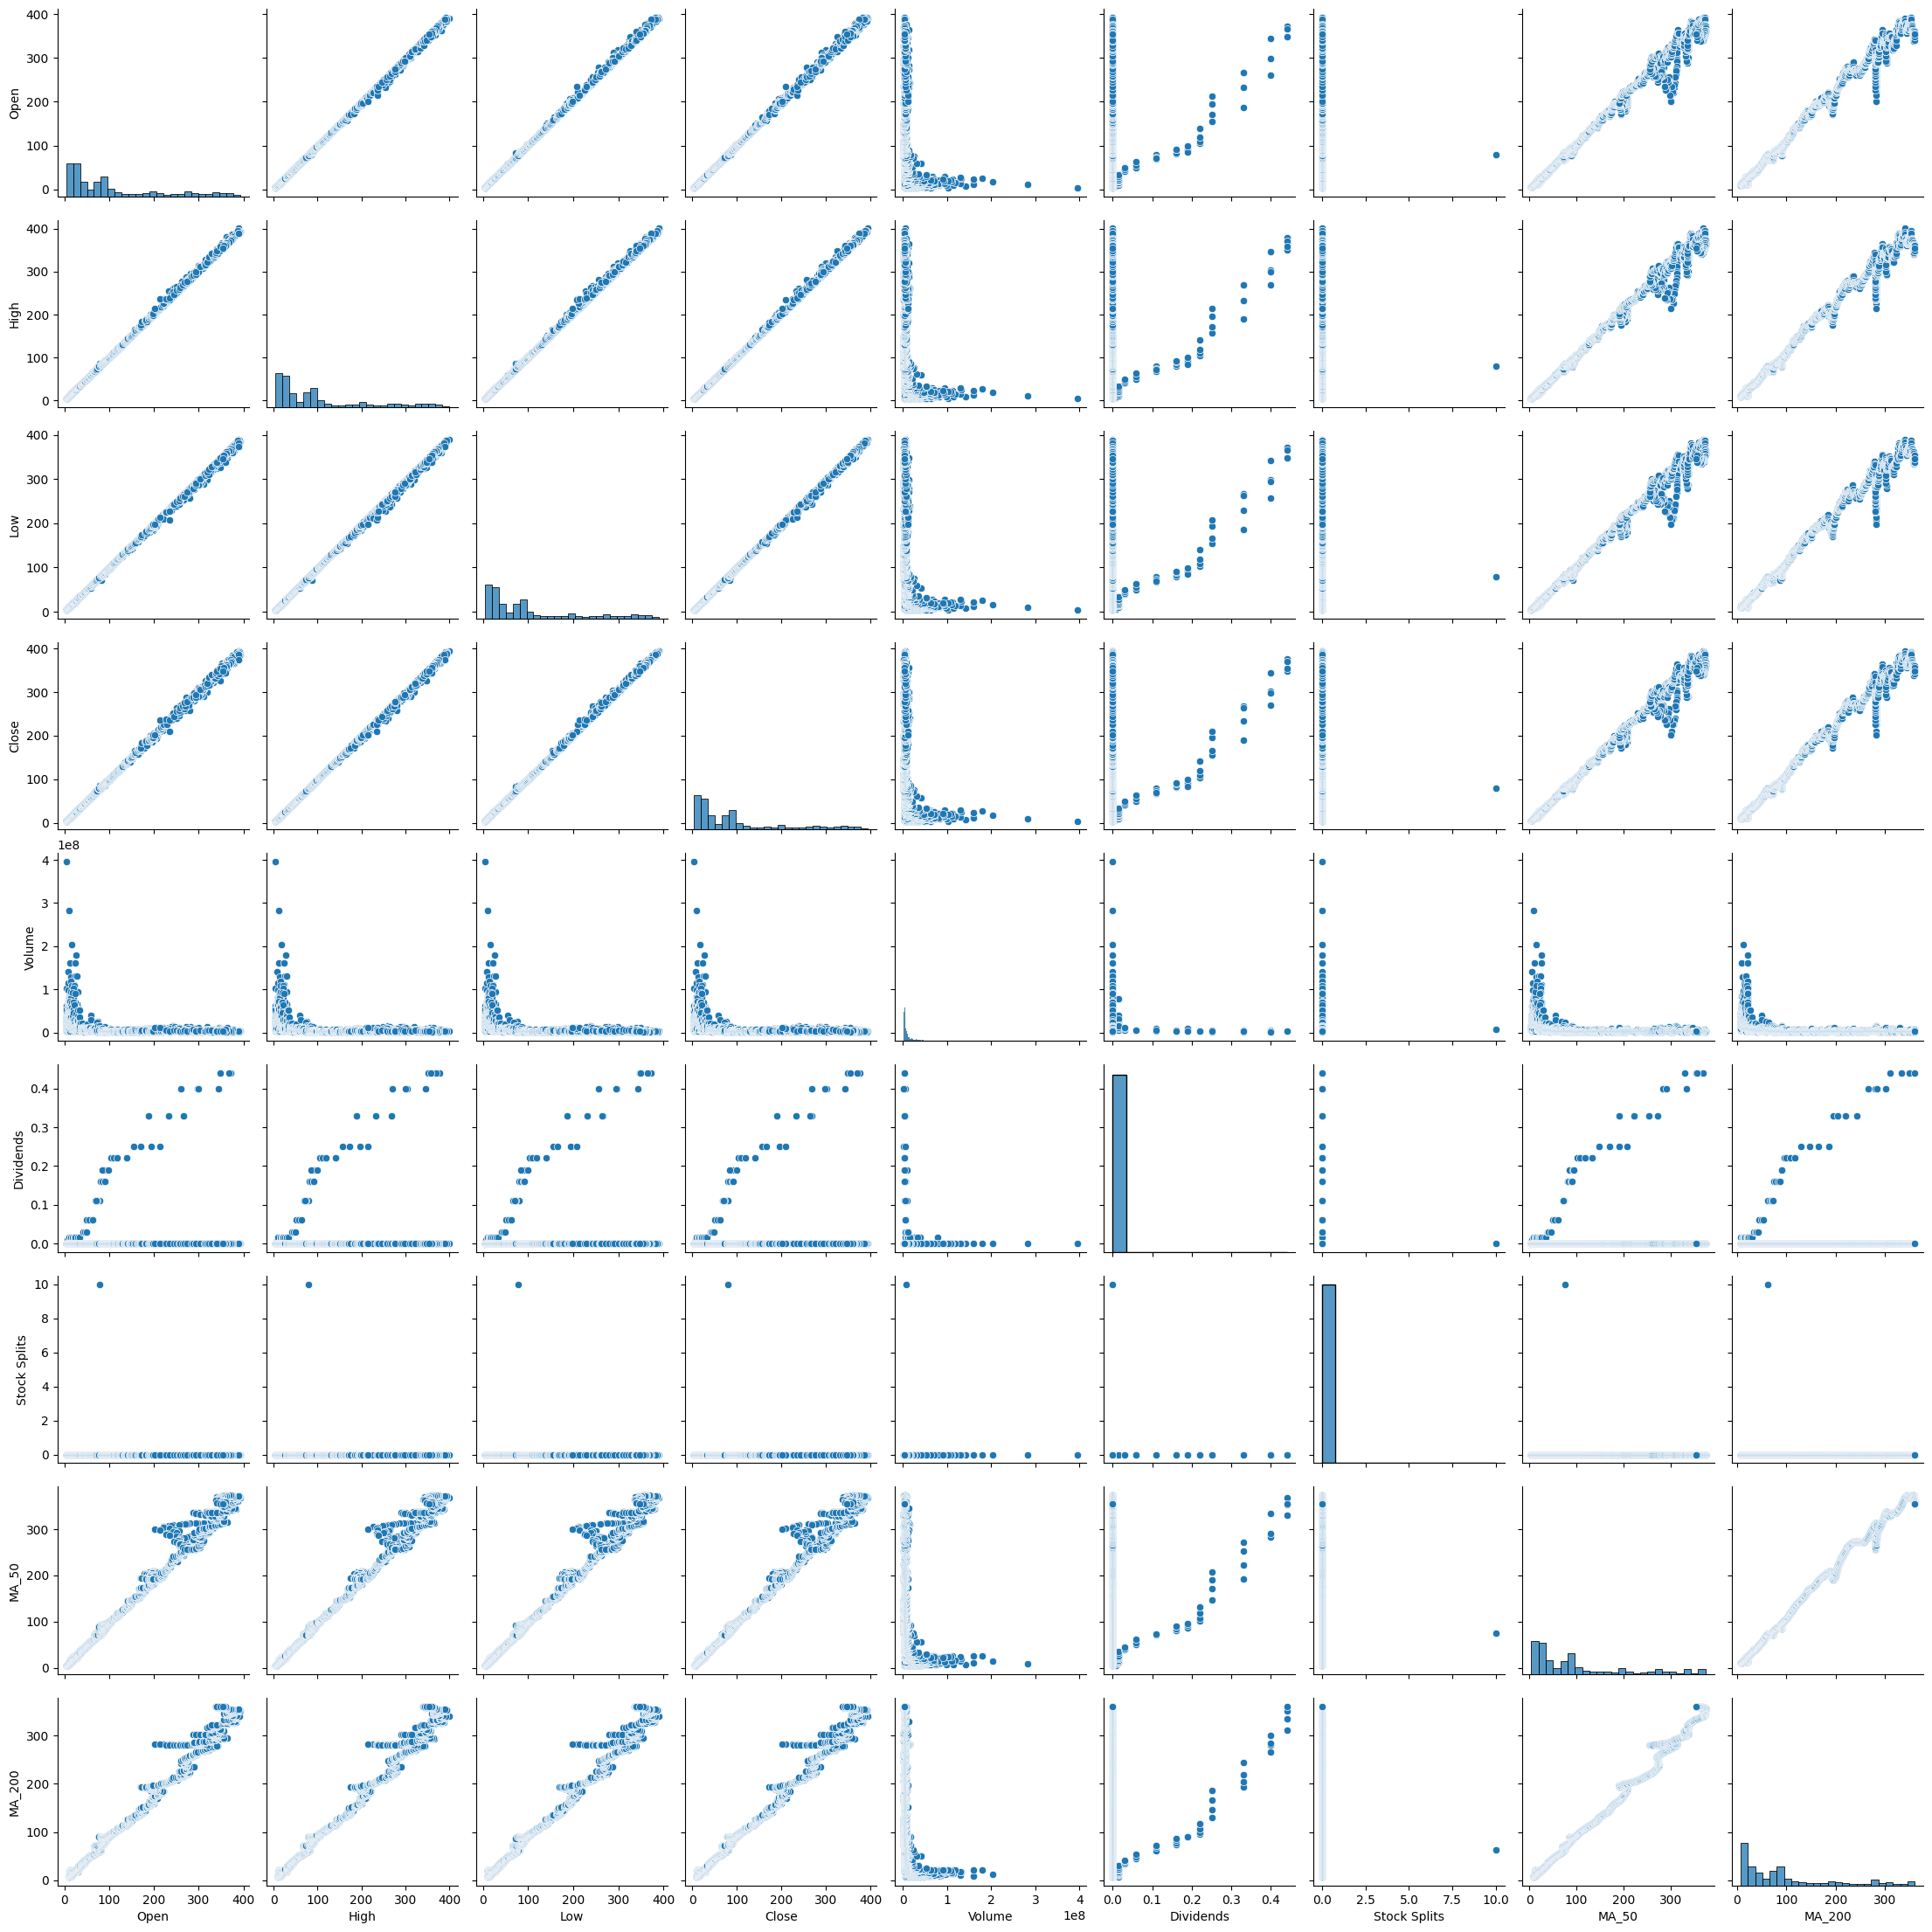

In [33]:
sns.pairplot(df)

## Predictive modeling

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [35]:
df.isna().sum()

Open              0
High              0
Low               0
Close             0
Volume            0
Dividends         0
Stock Splits      0
MA_50            49
MA_200          199
dtype: int64

In [36]:
df = df.dropna(subset=['MA_50', 'MA_200'])

In [37]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'MA_50', 'MA_200'],
      dtype='object')


In [38]:
features = df.drop(columns=['Close'])
target = df['Close']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=29)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=250, random_state=29)

rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=250, random_state=29)

In [39]:
y_pred_rf = rf_model.predict(X_test_scaled)

y_pred_rf

array([ 43.07935034,  74.25076013,  54.7504622 , 153.86757422,
       326.26218848,  25.95424327, 195.51963635, 259.42182904,
        18.18255861,  94.31124661,  79.26111951,  23.34645407,
        54.51091222,  72.13722263,  21.18908128,  22.35810924,
        22.96277795, 387.95745325, 344.75934558, 285.80044336,
        95.88330289,  86.40595837,  26.70248257, 234.14570667,
        23.55637967,  88.82401117, 126.30564999, 194.52354651,
        33.9173734 , 294.73491541,  14.68267211, 196.1408584 ,
       103.93925919,  15.21082298,  26.64634283,  22.44704271,
        72.85883353, 126.06256952,  54.58281223,  24.51138238,
        20.49819944,  70.86620734, 364.84153247,  94.62473624,
       305.00798047,  74.78446448,  91.45764609,  83.74750549,
        80.90628485,  16.07829181,  12.70279402,  97.85107742,
       254.84121259, 319.35247498,  20.798341  ,  37.4648479 ,
        93.44736661,  25.68424547,  39.08071422,  49.04844272,
        39.21322827, 204.0128728 , 108.39048068,  93.82

In [40]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=250, random_state=29),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR(),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor()
}

results = []

for name, model in models.items():
    if "SVR" in name:  # SVR needs scaled data
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Model evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R² Score": r2})

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)
print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 2938, number of used features: 7
[LightGBM] [Info] Start training from score 110.127991
                      Model        MAE       RMSE  R² Score
1          Ridge Regression   0.537744   1.175324  0.999880
0         Linear Regression   0.537744   1.175344  0.999880
4             Random Forest   0.729859   1.536976  0.999794
5         Gradient Boosting   0.960333   1.729563  0.999739
8                  LightGBM   0.883686   1.767777  0.999728
7                   XGBoost   0.937204   1.771567  0.999726
2          Lasso Regression   1.027056   2.078093  0.999623
3             Decision Tree   0.949101   2.131959  0.999604
6  Support Vector Regressor  57.966038

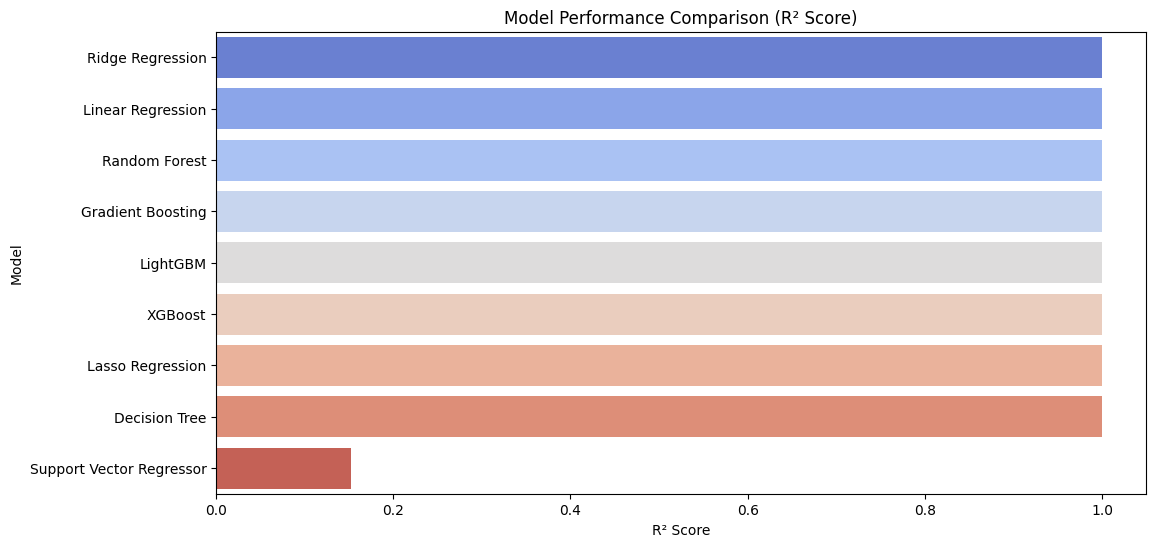

In [41]:
plt.figure(figsize=(12, 6))
sns.barplot(x="R² Score", y="Model", data=results_df, palette="coolwarm")
plt.title("Model Performance Comparison (R² Score)")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

                      Model     MAE (%)    RMSE (%)  R² Score (%)
0          Ridge Regression    0.927688    1.192052       99.9880
1         Linear Regression    0.927688    1.192073       99.9880
2             Random Forest    1.259115    1.558852       99.9794
3         Gradient Boosting    1.650127    1.751788       99.9740
4                  LightGBM    1.524489    1.792938       99.9728
5                   XGBoost    1.616816    1.796782       99.9726
6          Lasso Regression    1.771824    2.107670       99.9623
7             Decision Tree    1.602873    2.140139       99.9612
8  Support Vector Regressor  100.000000  100.000000       15.2384


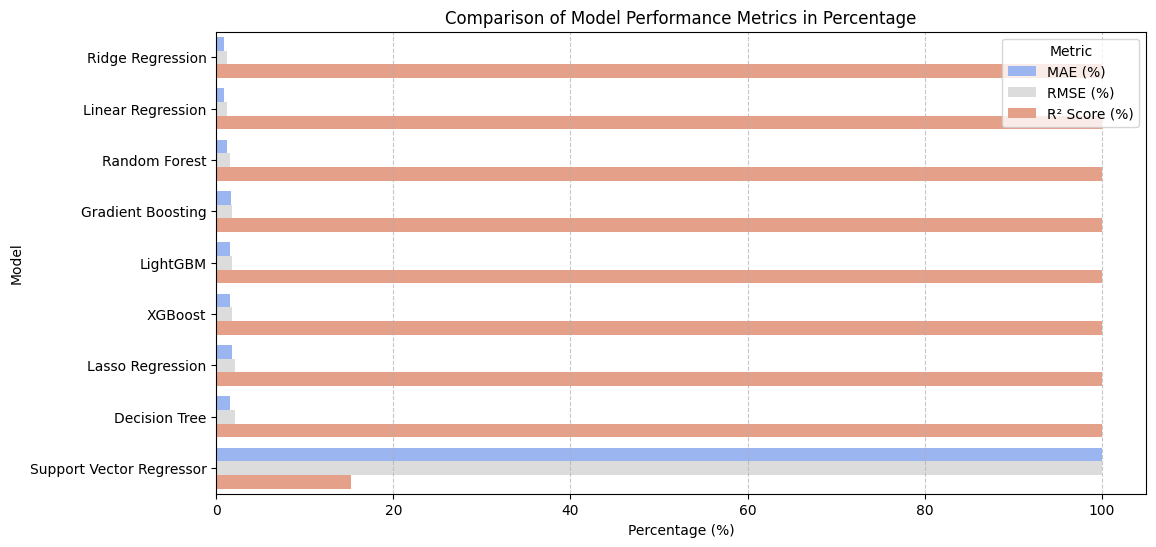

In [42]:
model_results = {
    "Model": [
        "Ridge Regression", "Linear Regression", "Random Forest",
        "Gradient Boosting", "LightGBM", "XGBoost", "Lasso Regression",
        "Decision Tree", "Support Vector Regressor"
    ],
    "MAE": [0.537744, 0.537744, 0.729859, 0.956513, 0.883686, 0.937204, 1.027056, 0.929122, 57.966038],
    "RMSE": [1.175324, 1.175344, 1.536976, 1.727205, 1.767777, 1.771567, 2.078093, 2.110106, 98.596677],
    "R² Score": [0.999880, 0.999880, 0.999794, 0.999740, 0.999728, 0.999726, 0.999623, 0.999612, 0.152384]
}

# Convert to DataFrame
df_results = pd.DataFrame(model_results)

# Convert to percentage (except R² score)
df_results["MAE (%)"] = (df_results["MAE"] / df_results["MAE"].max()) * 100
df_results["RMSE (%)"] = (df_results["RMSE"] / df_results["RMSE"].max()) * 100
df_results["R² Score (%)"] = df_results["R² Score"] * 100

# Drop raw values for cleaner output
df_results = df_results.drop(columns=["MAE", "RMSE", "R² Score"])

# Display results
print(df_results)

# --- Visualization ---
plt.figure(figsize=(12, 6))
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Percentage")

# Bar plot
sns.barplot(x="Percentage", y="Model", hue="Metric", data=df_melted, palette="coolwarm")

plt.xlabel("Percentage (%)")
plt.ylabel("Model")
plt.title("Comparison of Model Performance Metrics in Percentage")
plt.legend(title="Metric")
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

In [43]:
# Convert R² Score to Accuracy Percentage
df_results["Accuracy (%)"] = df_results["R² Score (%)"]

# Display Accuracy
df_results[["Model", "Accuracy (%)"]].sort_values(by="Accuracy (%)", ascending=False)


,Model,Accuracy (%)
0,Ridge Regression,99.9880
1,Linear Regression,99.9880
2,Random Forest,99.9794
3,Gradient Boosting,99.9740
4,LightGBM,99.9728
5,XGBoost,99.9726
6,Lasso Regression,99.9623
7,Decision Tree,99.9612
8,Support Vector Regressor,15.2384


## Thank you....pls upvote!!!!!!!!!